In [ ]:
# mount the data from google drive
from google.colab import drive
from google.colab import files
drive.mount("/content/drive")

# navigate to the project folder
%cd drive/MyDrive/projects/CVPR

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/projects/CVPR


In [ ]:
ls

annotations/            deepgaze/         figures/       label_ids1.csv  monodepth2/
attention/              deepgaze2/        fixations/     masks/          ms-coco/
attention1/             depth/            fixations.csv  masks1/         rescaled-output.jpg
centerbias_mit1003.npy  extracted_files/  images/        masks2/         test_mask_images/


In [ ]:
import pandas as pd
df = pd.read_csv('ms-coco/coco-freeview-fixation.csv')
df['image_name'] = df['image_name'].str[:-4]
my_image_list = df.image_name.unique()


from zipfile import ZipFile, BadZipFile
import os
import shutil

def extract_images_from_zip(zip_path, image_list, output_dir):
    """
    Extracts specific image files from a ZIP archive and saves them to a new folder called 'annotations',
    only if they are in the provided image list.

    Args:
        zip_path: Path to the ZIP file containing images in 'train2017' and 'val2017' folders.
        image_list: List of image filenames to be extracted (without directory paths).
        output_dir: Directory where images should be extracted.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    try:
        with ZipFile(zip_path, 'r') as zfile:
            # Get all files in the current ZIP
            all_files = zfile.namelist()

            # Filter PNG files in 'train2017' and 'val2017' folders and check if in image_list
            for img_file in all_files:

                if img_file.endswith('.png') and ('train2017/' in img_file or 'val2017/' in img_file):
                    img_name = os.path.basename(img_file)  # Get the image filename without path
                    # Check if this image is in the image list
                    if img_name[:-4] in image_list:
                        print(img_name)
                        # Extract the file to the output directory
                        zfile.extract(img_file, output_dir)

                        # Move file to root of output directory if it was in a subdirectory
                        if os.path.dirname(img_file):
                            src = os.path.join(output_dir, img_file)
                            dst = os.path.join(output_dir, img_name)
                            shutil.move(src, dst)

                        # Clean up empty directories
                        dir_path = os.path.join(output_dir, os.path.dirname(img_file))
                        if os.path.exists(dir_path) and not os.listdir(dir_path):
                            try:
                                os.rmdir(dir_path)
                            except OSError:
                                # Handle nested directories by trying to remove parent dirs
                                parent = dir_path
                                while parent and os.path.exists(parent):
                                    try:
                                        if not os.listdir(parent):
                                            os.rmdir(parent)
                                        parent = os.path.dirname(parent)
                                    except:
                                        break

                        print(f"Extracted: {img_name}")

    except BadZipFile:
        print(f"Error: {zip_path} is not a valid ZIP file")
    except Exception as e:
        print(f"Error processing {zip_path}: {str(e)}")

# Example usage
if __name__ == "__main__":
    # Path to the ZIP file containing 'train2017' and 'val2017' folders
    zip_file = "./ms-coco/stuffthingmaps_trainval2017.zip"

    # Output directory for extracted images
    output_directory = "./ms-coco/annotations1"

    # Extract images from the ZIP file if they are in the image list
    extract_images_from_zip(zip_file, my_image_list, output_directory)

In [ ]:
import cv2
import os
import numpy as np

def resize_and_fit(image_path, target_height, canvas_width, output_path):
    """
    Resize an image to match the target height while keeping the aspect ratio.
    If the resized image exceeds the width, crop the excess from both sides.

    Args:
        image_path (str): Path to input image.
        target_height (int): Desired height.
        canvas_width (int): Width of the final black canvas.
        output_path (str): Path to save output image.
    """
    # Load image
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    # Check if image has 1 channel (grayscale) or 3 channels (RGB)
    if len(image.shape) == 2:  # Grayscale image
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)  # Convert to RGB

    orig_h, orig_w = image.shape[:2]

    # Compute scale factor and new dimensions based on target height
    scale = target_height / orig_h
    new_w = int(orig_w * scale)
    new_h = target_height

    # Resize image while maintaining aspect ratio
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)

    # If the new width exceeds the canvas width, crop the excess
    if new_w > canvas_width:
        # Calculate the crop width (how much to remove from both sides)
        excess_width = new_w - canvas_width
        crop_left = excess_width // 2
        crop_right = excess_width - crop_left

        # Crop the image
        resized = resized[:, crop_left:new_w - crop_right]

    # Create black canvas of (target_height, canvas_width)
    output = np.zeros((target_height, canvas_width, 3), dtype=np.uint8)

    # Compute horizontal centering
    start_x = (canvas_width - resized.shape[1]) // 2

    # Place resized image onto black canvas
    output[:, start_x:start_x + resized.shape[1]] = resized

    # Save result
    cv2.imwrite(output_path, output)

def process_images_in_folder(input_folder, output_folder, target_height, canvas_width):
    """
    Loop through a folder of images, resize them, and save into the specified output folder.

    Args:
        input_folder (str): Folder containing images to resize.
        output_folder (str): Folder to save resized images.
        target_height (int): Desired height of the resized images.
        canvas_width (int): Width of the final black canvas.
    """
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    # Loop through all files in the input folder
    for filename in os.listdir(input_folder):
        input_path = os.path.join(input_folder, filename)

        # Only process image files (skip non-image files)
        if os.path.isfile(input_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            # Define output file path
            output_path = os.path.join(output_folder, filename)

            # Resize and save image
            resize_and_fit(input_path, target_height, canvas_width, output_path)
            print(f"Processed: {filename}")

# Example usage
input_folder = "./ms-coco/annotations1"  # Folder containing input images
output_folder = "./ms-coco/rescaled-annotations"  # Folder to save resized images
target_height = 1050  # Desired height of the resized images
canvas_width = 1680  # Canvas width

# Process all images in the folder
process_images_in_folder(input_folder, output_folder, target_height, canvas_width)


Processed: 000000319315.png
Processed: 000000052153.png
Processed: 000000083884.png
Processed: 000000223404.png
Processed: 000000073549.png
Processed: 000000511236.png
Processed: 000000449394.png
Processed: 000000415694.png
Processed: 000000256189.png
Processed: 000000278243.png
Processed: 000000530905.png
Processed: 000000179696.png
Processed: 000000314837.png
Processed: 000000331822.png
Processed: 000000419971.png
Processed: 000000206363.png
Processed: 000000471345.png
Processed: 000000532131.png
Processed: 000000445338.png
Processed: 000000390996.png
Processed: 000000247680.png
Processed: 000000004444.png
Processed: 000000005486.png
Processed: 000000557610.png
Processed: 000000490908.png
Processed: 000000468203.png
Processed: 000000200654.png
Processed: 000000349915.png
Processed: 000000256611.png
Processed: 000000082858.png
Processed: 000000495867.png
Processed: 000000084701.png
Processed: 000000411104.png
Processed: 000000228260.png
Processed: 000000560158.png
Processed: 000000526

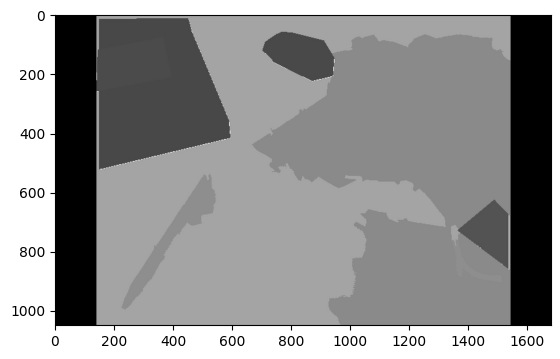

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
# Load the image using Pillow
image = Image.open("./ms-coco/rescaled-annotations/000000205560.png")

# Plot the image using Matplotlib
plt.imshow(image, cmap='magma')

In [ ]:
import os
import numpy as np
from PIL import Image

def convert_images_to_numpy(folder_path, output_folder=None):
    """
    Loops through all image files in a folder, converts them to NumPy arrays, and saves as .npy files.

    Args:
        folder_path: Path to the folder containing images.
        output_folder: Optional folder to save .npy files (default: same as folder_path).
    """
    if output_folder is None:
        output_folder = folder_path  # Save in the same directory if no output folder is specified
    os.makedirs(output_folder, exist_ok=True)  # Create output directory if it doesn't exist

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        # Check if it's an image file (supports PNG, JPG, JPEG)
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                with Image.open(file_path) as img:
                    numpydata = np.asarray(img)  # Convert image to NumPy array

                    # Save the NumPy array as a .npy file
                    npy_filename = os.path.splitext(filename)[0] + ".npy"
                    npy_path = os.path.join(output_folder, npy_filename)
                    np.save(npy_path, numpydata)

                    print(f"Saved: {npy_filename}")

            except Exception as e:
                print(f"Error processing {filename}: {e}")

# Example usage
if __name__ == "__main__":
    folder = "./ms-coco/rescaled-annotations"  # Change to your image folder
    output_folder = "./ms-coco/object_arrays"  # Change to desired output folder (or set to None to save in place)

    convert_images_to_numpy(folder, output_folder)


Saved: 000000306466.npy
Saved: 000000486114.npy
Saved: 000000155591.npy
Saved: 000000074357.npy
Saved: 000000547154.npy
Saved: 000000369125.npy
Saved: 000000329613.npy
Saved: 000000457401.npy
Saved: 000000376065.npy
Saved: 000000442929.npy
Saved: 000000439399.npy
Saved: 000000335473.npy
Saved: 000000044039.npy
Saved: 000000246928.npy
Saved: 000000010037.npy
Saved: 000000520485.npy
Saved: 000000402507.npy
Saved: 000000513240.npy
Saved: 000000215226.npy
Saved: 000000538198.npy
Saved: 000000092323.npy
Saved: 000000528147.npy
Saved: 000000324381.npy
Saved: 000000398986.npy
Saved: 000000000643.npy
Saved: 000000115544.npy
Saved: 000000221973.npy
Saved: 000000114861.npy
Saved: 000000167180.npy
Saved: 000000309060.npy
Saved: 000000217071.npy
Saved: 000000363956.npy
Saved: 000000318736.npy
Saved: 000000060040.npy
Saved: 000000518415.npy
Saved: 000000204826.npy
Saved: 000000355748.npy
Saved: 000000295166.npy
Saved: 000000349841.npy
Saved: 000000102459.npy
Saved: 000000189646.npy
Saved: 000000288

In [ ]:
import os
import numpy as np

def process_numpy_arrays(folder_path, values_to_replace, output_folder=None):
    """
    Loops through all .npy files in a folder, replaces specified values with 0,
    saves the modified arrays, and returns a list of unique values in the final arrays.

    Args:
        folder_path: Path to the folder containing .npy files.
        values_to_replace: List of values to replace with 0.
        output_folder: Optional folder to save modified .npy files (default: overwrite in the same folder).

    Returns:
        A sorted list of unique values found in the final arrays.
    """
    if output_folder is None:
        output_folder = folder_path  # Save in place if no output folder is specified
    os.makedirs(output_folder, exist_ok=True)  # Create output directory if it doesn't exist

    unique_values_set = set()  # Set to collect unique values

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        # Process only .npy files
        if filename.endswith(".npy"):
            try:
                # Load NumPy array
                numpy_data = np.load(file_path)

                # Replace values in the list with 0
                for value in values_to_replace:
                    numpy_data[numpy_data == value] = 0

                # Update unique values set with final array values
                unique_values_set.update(np.unique(numpy_data))

                # Save modified array
                output_path = os.path.join(output_folder, filename)
                np.save(output_path, numpy_data)

                print(f"Processed and saved: {filename}")

            except Exception as e:
                print(f"Error processing {filename}: {e}")




# Example usage
if __name__ == "__main__":
    folder = "./ms-coco/object_arrays"  # Change to your folder containing .npy files
    values_to_replace = [101, 102, 103, 114, 115, 116, 117, 118, 120, 124,  126, 140, 149, 157, 171, 172, 173, 174, 175, 176, 177, 178, 183]  # List of values to replace with 0


# Subtract 1 from each value
    #values_to_replace = [x - 1 for x in values_to_replace]



    output_folder = "./ms-coco/modified_numpy_arrays"  # Change to desired output folder (or set to None to overwrite)

    process_numpy_arrays(folder, values_to_replace, output_folder)



Processed and saved: 000000341437.npy
Processed and saved: 000000440623.npy
Processed and saved: 000000252340.npy
Processed and saved: 000000006810.npy
Processed and saved: 000000027873.npy
Processed and saved: 000000327413.npy
Processed and saved: 000000004463.npy
Processed and saved: 000000327768.npy
Processed and saved: 000000277630.npy
Processed and saved: 000000209931.npy
Processed and saved: 000000097080.npy
Processed and saved: 000000054013.npy
Processed and saved: 000000452650.npy
Processed and saved: 000000018571.npy
Processed and saved: 000000581829.npy
Processed and saved: 000000341894.npy
Processed and saved: 000000534024.npy
Processed and saved: 000000010058.npy
Processed and saved: 000000313015.npy
Processed and saved: 000000042748.npy
Processed and saved: 000000495528.npy
Processed and saved: 000000188826.npy
Processed and saved: 000000521473.npy
Processed and saved: 000000305445.npy
Processed and saved: 000000576956.npy
Processed and saved: 000000432297.npy
Processed an

**Image size.** Each 1050 x 1680 image input was resized to 320 x 512 pixels to reduce computation. reduce by .3 for deepgaze.


In [ ]:
import os
import shutil

def collapse_folders(source_dir, dest_dir):
    """
    Copies all files from subdirectories within source_dir to dest_dir,
    creating dest_dir if it doesn't exist.
    """
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    for root, _, files in os.walk(source_dir):
        for filename in files:
            file_path = os.path.join(root, filename)
            dest_path = os.path.join(dest_dir, filename)

            # Avoid overwriting existing files
            if not os.path.exists(dest_path):
                shutil.copy2(file_path, dest_path)
            else:
                print(f"File {filename} already exists in destination, skipping.")

# Example usage:
source_directory = "ms-coco/images"
destination_directory = "ms-coco/coco-images"
collapse_folders(source_directory, destination_directory)

In [ ]:
import os

def count_files_in_directory(folder_path):
    """Counts the number of files in a given directory.

    Args:
        folder_path: The path to the directory.

    Returns:
        The number of files in the directory, or None if the directory does not exist.
    """
    if not os.path.exists(folder_path):
        print(f"Error: Directory '{folder_path}' not found.")
        return None

    file_count = 0
    for item in os.listdir(folder_path):
        item_path = os.path.join(folder_path, item)
        if os.path.isfile(item_path):
            file_count += 1
    return file_count

# Example usage:
folder_path = "ms-coco/coco-images"  # Replace with the actual path to your folder
num_files = count_files_in_directory(folder_path)

if num_files is not None:
    print(f"Number of files in '{folder_path}': {num_files}")